In [1]:
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from zoology.analysis.utils import fetch_wandb_runs

In [14]:
def plot(
    df: pd.DataFrame,
    max_seq_len: int = 512,
):
    seq_len_key = "data.train_configs.0.input_seq_len"

    plot_df = df.groupby([
        "model.sequence_mixer.name",
        "model.d_model",
        seq_len_key
    ])["valid/accuracy"].max().reset_index()
    breakpoint()

    sns.set_theme(style="whitegrid")
    g = sns.relplot(
        data=plot_df[plot_df[seq_len_key] <= max_seq_len],
        y="valid/accuracy",
        col=seq_len_key,
        x="model.d_model",
        hue="model.sequence_mixer.name",
        kind="line",
        marker="o",
        height=5,
        aspect=1,
    )
    g.set(xscale="log", ylabel="Accuracy", xlabel="Model dimension")

    # Set custom x-ticks
    ticks = [256] # Modify this list as needed
    for ax in g.axes.flat:
        ax.set_xticks(ticks)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter()) # This will keep the tick labels as integers rather than in scientific notation

    # Set custom y-ticks
    y_ticks = [0, 0.25, 0.5, 0.75, 1.0]
    for ax in g.axes.flat:
        ax.set_yticks(y_ticks)

    for ax, title in zip(g.axes.flat, g.col_names):
        ax.set_title(f"Sequence Length: {title}")

Index(['run_id', 'name', 'project', 'user', 'state', 'data.seed',
       'data.cache_dir', 'data.batch_size', 'data.force_cache',
       'data.test_configs.0.vocab_size',
       ...
       'gradients/graph_2backbone.layers.1.norm1.bias',
       'gradients/graph_2backbone.layers.1.norm1.weight',
       'gradients/graph_2backbone.layers.1.norm2.bias',
       'gradients/graph_2backbone.layers.1.norm2.weight',
       'gradients/graph_2backbone.layers.1.sequence_mixer.Wqkv.bias',
       'gradients/graph_2backbone.layers.1.sequence_mixer.Wqkv.weight',
       'gradients/graph_2backbone.layers.1.sequence_mixer.out_proj.bias',
       'gradients/graph_2backbone.layers.1.sequence_mixer.out_proj.weight',
       'gradients/graph_2backbone.ln_f.bias',
       'gradients/graph_2backbone.ln_f.weight'],
      dtype='object', length=111)


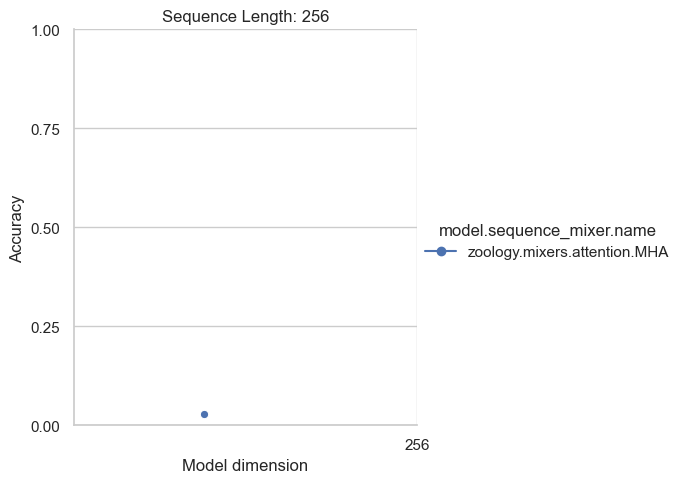

In [15]:

df = fetch_wandb_runs(
    launch_id=[
        "default-2024-10-14-15-06-08"
        # "default-2024-10-14-15-06-08"
    ], 
    project_name="eval_mqar"
)
print(df.columns)
# df["data.input_seq_len"] = df["data.input_seq_len"].fillna(df["data.0.input_seq_len"])
plot(df=df, max_seq_len=1024)
plt.savefig("results.png")
